#  Movie Genre Classification

### CODSOFT Machine Learning Internship

**Task 1:** Movie Genre Classification using Machine Learning

**Objective:** Build a machine learning model that predicts the genre of a movie based on its plot summary using TF-IDF and Logistic Regression.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Training Data

In [ ]:
train_data = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    names=["ID", "TITLE", "GENRE", "DESCRIPTION"],
    engine="python"
)

train_data.head()

,ID,TITLE,GENRE,DESCRIPTION
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


## Step 3: Check Dataset Shape

In [ ]:
print("Rows and Columns:")
print(train_data.shape)

Rows and Columns:
(54214, 4)


## Step 4: Dataset Information

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           54214 non-null  int64 
 1   TITLE        54214 non-null  object
 2   GENRE        54214 non-null  object
 3   DESCRIPTION  54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


## Step 5: Check Missing Values

In [ ]:
train_data.isnull().sum()

,0
ID,0
TITLE,0
GENRE,0
DESCRIPTION,0


## Step 6: Genre Distribution

In [ ]:
train_data["GENRE"].value_counts().head(10)

,count
GENRE,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


## Step 7: Visualize Genre Distribution

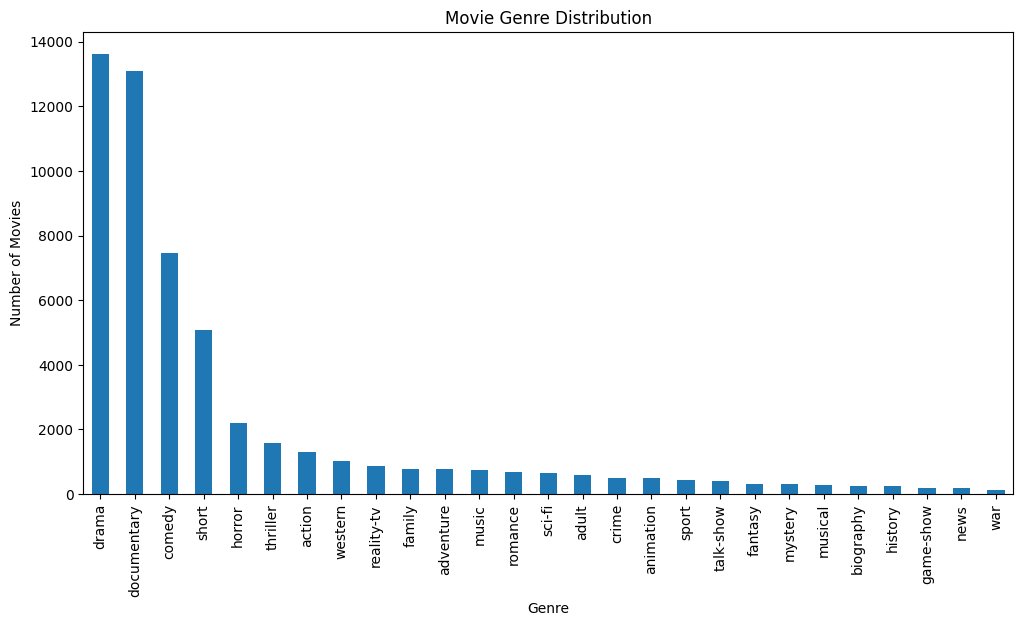

In [ ]:
train_data["GENRE"].value_counts().plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=90)

plt.show()

## Step 8: Prepare Features and Labels

In [ ]:
X = train_data["DESCRIPTION"]
y = train_data["GENRE"]

print(X.head())
print(y.head())

0    Listening in to a conversation between his doc...
1    A brother and sister with a past incestuous re...
2    As the bus empties the students for their fiel...
3    To help their unemployed father make ends meet...
4    The film's title refers not only to the un-rec...
Name: DESCRIPTION, dtype: object
0       drama
1    thriller
2       adult
3       drama
4       drama
Name: GENRE, dtype: object


## Step 9: Convert Text into Numbers (TF-IDF Vectorization)

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Vectorization Completed!")
print(X_tfidf.shape)

TF-IDF Vectorization Completed!
(54214, 5000)


## Step 10: Split Dataset into Training and Testing

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (43371, 5000)
Testing Data Shape: (10843, 5000)


## Step 11: Train Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Step 12: Make Predictions

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['comedy' 'drama' 'documentary' 'horror' 'music' 'drama' 'documentary'
 'documentary' 'documentary' 'drama']


## Step 13: Model Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.5799133081250576


## Step 14: Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      action       0.51      0.25      0.34       263
       adult       0.75      0.21      0.33       112
   adventure       0.42      0.14      0.21       139
   animation       0.60      0.09      0.15       104
   biography       0.00      0.00      0.00        61
      comedy       0.51      0.59      0.55      1443
       crime       0.29      0.02      0.04       107
 documentary       0.66      0.85      0.74      2659
       drama       0.54      0.78      0.64      2697
      family       0.39      0.07      0.12       150
     fantasy       0.00      0.00      0.00        74
   game-show       0.94      0.42      0.59        40
     history       0.00      0.00      0.00        45
      horror       0.64      0.56      0.60       431
       music       0.62      0.47      0.54       144
     musical       1.00      0.02      0.04        50
     mystery       0.00      0.00      0.00        56
        news       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 15: Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  67    0    1    0    0   26    2   31   95    0    0    0    0   12
     0    0    0    0    0    0    5    6    5    0   13    0    0]
 [   0   24   13    0    0   32    0    6   27    0    0    0    0    1
     0    0    0    0    0    0    0    7    0    0    1    0    1]
 [   6    0   19    0    0   20    0   27   37    1    0    0    0   10
     0    0    0    0    1    0    4    9    1    0    2    0    2]
 [   1    0    2    9    0   23    0   17   22    9    1    0    0    2
     1    0    0    0    0    0    6   11    0    0    0    0    0]
 [   0    0    0    0    0    2    0   38   18    0    0    0    0    0
     0    0    0    0    0    0    0    3    0    0    0    0    0]
 [   6    1    1    1    0  847    1   91  412    2    0    0    0   11
     2    0    0    0    8    1    1   48    2    1    4    0    3]
 [   8    0    0    0    0   20    2   13   47    0    0    0    0    5
     0    0    0    0    0    0    1    4    0    0    7    0    0]
 [   3    1    1    

## Step 16: Train Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.5225491100249009


## Step 17: Train Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.5694918380521996


## Step 18: Compare AI Models

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.579913
1,Naive Bayes,0.522549
2,Support Vector Machine,0.569492


## Step 19: Choose the best model

In [ ]:
models = {
    "Logistic Regression": model,
    "Naive Bayes": nb_model,
    "SVM": svm_model
}

accuracies = {
    "Logistic Regression": accuracy,
    "Naive Bayes": nb_accuracy,
    "SVM": svm_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", accuracies[best_model_name])

Best Model: Logistic Regression
Best Accuracy: 0.5799133081250576


## Step 20: Save the Best Model

In [ ]:
import joblib

joblib.dump(lr_model,"best_movie_genre_model.pkl")
joblib.dump(tfidf,"tfidf_vectorizer.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [ ]:
!ls

best_movie_genre_model.pkl  test_data_solution.txt  tfidf_vectorizer.pkl
sample_data		    test_data.txt	    train_data.txt


##Test1

In [ ]:
sample_movie = [
    "A group of friends enter a haunted house and are chased by evil spirits."
]

sample_vector = tfidf.transform(sample_movie)

prediction = best_model.predict(sample_vector)

print("Movie Plot:", sample_movie[0])
print("Predicted Genre:", prediction[0])

Movie Plot: A group of friends enter a haunted house and are chased by evil spirits.
Predicted Genre: horror


##Test2

In [ ]:
sample_movie = [
    "An ex-soldier fights against a dangerous criminal organization to stop a terrorist attack."
]

sample_vector = tfidf.transform(sample_movie)

prediction = best_model.predict(sample_vector)

print("Movie Plot:", sample_movie[0])
print("Predicted Genre:", prediction[0])

Movie Plot: An ex-soldier fights against a dangerous criminal organization to stop a terrorist attack.
Predicted Genre: action


##Test3

In [ ]:
sample_movie = [
    "Two college students fall in love despite their families being rivals and overcome many challenges together."
]

sample_vector = tfidf.transform(sample_movie)

prediction = best_model.predict(sample_vector)

print("Movie Plot:", sample_movie[0])
print("Predicted Genre:", prediction[0])

Movie Plot: Two college students fall in love despite their families being rivals and overcome many challenges together.
Predicted Genre: drama


## Step 21: Download Model Files

In [ ]:
from google.colab import files

files.download("best_movie_genre_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project successfully classified movie genres using machine learning techniques.
Three classification algorithm :—
Logistic Regression,
Naive Bayes, and
Support Vector Machine (SVM)—were trained and evaluated using TF-IDF vectorized movie plot descriptions.

Result:-
Logic Regression-57.99% [Highest Accuracy]

SVM-56.94%

Naive Bytes-52.25%

After comparing the performance of all models, the best-performing model was selected, saved, and tested on new movie plot summaries.
The project demonstrates how natural language processing and machine learning can be used for automated movie genre prediction.